# These all will happen in this ML notebook

Clean Dataset
      ↓
Define Features (X)
      ↓
Define Target (y)
      ↓
Remove Leakage
      ↓
Train/Test Split
      ↓
Categorical Encoding
      ↓
Numerical Processing
      ↓
Train Multiple Models
      ↓
Evaluate Models
      ↓
Select Best Model
      ↓
Save Model

In [1]:
# Import libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv(
    "../data/processed/student_learning_data_clean.csv"
)

df.head()

,student_id,age,gender,department,semester,attendance_pct,assignment_avg,assignment_completion_pct,quiz_avg,quiz_attempts,...,video_completion_pct,previous_gpa,previous_failures,late_assignments,discussion_participation,support_requested,midterm_score,final_score,performance_level,risk_level
0,STU100001,22,Male,ECE,5,66.1,74.9,44.8,60.1,12,...,62.9,6.77,0,4,9.0,Yes,57.1,58.5,Average,Medium
1,STU100002,18,Female,ECE,8,89.1,59.8,69.1,54.5,12,...,69.9,5.17,1,0,14.0,No,71.8,65.2,Good,Low
2,STU100003,23,Female,ECE,5,76.9,68.6,96.7,79.3,14,...,74.4,7.24,0,0,12.0,No,67.1,80.7,Excellent,Low
3,STU100004,22,Male,ECE,4,89.0,78.8,52.1,49.8,12,...,67.9,7.53,0,1,16.0,Yes,72.0,56.7,Average,Medium
4,STU100005,23,Female,MECH,4,62.0,47.7,47.7,35.3,10,...,71.3,4.29,3,3,6.0,Yes,46.1,40.4,Poor,High


In [3]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (8000, 25)

Columns:
['student_id', 'age', 'gender', 'department', 'semester', 'attendance_pct', 'assignment_avg', 'assignment_completion_pct', 'quiz_avg', 'quiz_attempts', 'study_hours_week', 'participation_score', 'lms_login_count', 'lms_active_days', 'resources_accessed', 'video_completion_pct', 'previous_gpa', 'previous_failures', 'late_assignments', 'discussion_participation', 'support_requested', 'midterm_score', 'final_score', 'performance_level', 'risk_level']


In [4]:
target = "risk_level"

y = df[target]

y.value_counts()

risk_level
Medium    3475
Low       2617
High      1908
Name: count, dtype: int64

In [5]:
columns_to_exclude = [
    "student_id",
    "final_score",
    "performance_level",
    "risk_level"
]

In [6]:
X = df.drop(
    columns=columns_to_exclude
)

y = df["risk_level"]

In [7]:
print("Features:", X.shape)
print("Target:", y.shape)

Features: (8000, 21)
Target: (8000,)


In [8]:
X = X.drop(
    columns=["gender"]
)
#we exclude gender from the first predictive model unless there is a clear educational justification and we later perform a fairness review.

In [11]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "str"]
).columns.tolist()

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['age', 'semester', 'attendance_pct', 'assignment_avg', 'assignment_completion_pct', 'quiz_avg', 'quiz_attempts', 'study_hours_week', 'participation_score', 'lms_login_count', 'lms_active_days', 'resources_accessed', 'video_completion_pct', 'previous_gpa', 'previous_failures', 'late_assignments', 'discussion_participation', 'midterm_score']

Categorical Features:
['department', 'support_requested']


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [13]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (6400, 20)
Testing data: (1600, 20)


In [14]:
# Cell 12 —
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

In [15]:
# Numerical processing
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [16]:
# Categorical Processing
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [17]:
# combine both pipelines
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numeric_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ]
)

NOW WE HAVE

                  PREPROCESSOR
                      │
           ┌──────────┴──────────┐
           ▼                     ▼
       Numerical             Categorical
           │                     │
        Impute                 Impute
           │                     │
         Scale                 Encode
           │                     │
           └──────────┬──────────┘
                      ▼
                MODEL-READY DATA

In [48]:
# Import models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Add hyperparameter tuning tools
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

In [19]:
logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                random_state=42
            )
        )
    ]
)

In [20]:
logistic_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](3,)","['High','Low','Medium']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['age','department','semester',...,'discussion_participation', 'support_requested','midterm_score']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).

In [21]:
# Model 2 — Decision Tree
decision_tree_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            DecisionTreeClassifier(
                max_depth=8,
                random_state=42
            )
        )
    ]
)

decision_tree_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](3,)","['High','Low','Medium']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['age','department','semester',...,'discussion_participation', 'support_requested','midterm_score']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).

In [49]:
# Model 3 — Random Forest with Hyperparameter Tuning

# 1. Base Pipeline
base_rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

# 2. Define Hyperparameter Search Space
# Note: Use 'model__' prefix because the pipeline step name is 'model'
param_dist = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__max_depth': [8, 12, 16, 20, 25, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2']
}

# 3. Setup RandomizedSearchCV
rf_search = RandomizedSearchCV(
    estimator=base_rf_pipeline,
    param_distributions=param_dist,
    n_iter=25,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# 4. Run Search on Training Data
rf_search.fit(X_train, y_train)

# 5. Display Best Hyperparameters & Best CV Score
print("Best Hyperparameters Found:")
print(rf_search.best_params_)
print(f"\nBest 5-Fold Cross-Validation Accuracy: {rf_search.best_score_:.4f}")

# 6. Assign Best Estimator back to random_forest_pipeline
random_forest_pipeline = rf_search.best_estimator_


Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best Hyperparameters Found:
{'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__min_samples_leaf': 4, 'model__max_features': 'log2', 'model__max_depth': None}

Best 5-Fold Cross-Validation Accuracy: 0.7144


In [50]:
# make predictions
y_pred_logistic = logistic_pipeline.predict(X_test)

y_pred_tree = decision_tree_pipeline.predict(X_test)

y_pred_rf = random_forest_pipeline.predict(X_test)

In [51]:
# PART 5 — Evaluate the models
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [52]:
def evaluate_model(
    model_name,
    y_true,
    y_pred
):
    print("=" * 60)
    print(model_name)
    print("=" * 60)

    print(
        "Accuracy:",
        round(
            accuracy_score(y_true, y_pred),
            4
        )
    )

    print(
        "Precision:",
        round(
            precision_score(
                y_true,
                y_pred,
                average="weighted"
            ),
            4
        )
    )

    print(
        "Recall:",
        round(
            recall_score(
                y_true,
                y_pred,
                average="weighted"
            ),
            4
        )
    )

    print(
        "F1 Score:",
        round(
            f1_score(
                y_true,
                y_pred,
                average="weighted"
            ),
            4
        )
    )

    print("\nClassification Report:")
    print(
        classification_report(
            y_true,
            y_pred
        )
    )

In [26]:
# Evaluate all three
evaluate_model(
    "Logistic Regression",
    y_test,
    y_pred_logistic
)

evaluate_model(
    "Decision Tree",
    y_test,
    y_pred_tree
)

evaluate_model(
    "Random Forest",
    y_test,
    y_pred_rf
)

Logistic Regression
Accuracy: 0.7087
Precision: 0.7133
Recall: 0.7087
F1 Score: 0.7097

Classification Report:
              precision    recall  f1-score   support

        High       0.76      0.68      0.72       382
         Low       0.76      0.72      0.74       523
      Medium       0.65      0.72      0.68       695

    accuracy                           0.71      1600
   macro avg       0.72      0.71      0.71      1600
weighted avg       0.71      0.71      0.71      1600

Decision Tree
Accuracy: 0.6587
Precision: 0.6684
Recall: 0.6587
F1 Score: 0.6595

Classification Report:
              precision    recall  f1-score   support

        High       0.72      0.59      0.65       382
         Low       0.73      0.65      0.69       523
      Medium       0.60      0.70      0.65       695

    accuracy                           0.66      1600
   macro avg       0.68      0.65      0.66      1600
weighted avg       0.67      0.66      0.66      1600

Random Forest
Accuracy

In [53]:
evaluate_model(
    "Random Forest",
    y_test,
    y_pred_rf
)

Random Forest
Accuracy: 0.7037
Precision: 0.7119
Recall: 0.7037
F1 Score: 0.7046

Classification Report:
              precision    recall  f1-score   support

        High       0.76      0.64      0.69       382
         Low       0.77      0.70      0.73       523
      Medium       0.64      0.74      0.69       695

    accuracy                           0.70      1600
   macro avg       0.72      0.69      0.71      1600
weighted avg       0.71      0.70      0.70      1600



In [54]:
# PART 6 — Compare models in a table
results = []

models = {
    "Logistic Regression": (
        logistic_pipeline,
        y_pred_logistic
    ),
    "Decision Tree": (
        decision_tree_pipeline,
        y_pred_tree
    ),
    "Random Forest": (
        random_forest_pipeline,
        y_pred_rf
    )
}

for name, (model, predictions) in models.items():

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(
            y_test,
            predictions
        ),
        "Precision": precision_score(
            y_test,
            predictions,
            average="weighted"
        ),
        "Recall": recall_score(
            y_test,
            predictions,
            average="weighted"
        ),
        "F1 Score": f1_score(
            y_test,
            predictions,
            average="weighted"
        )
    })

results_df = pd.DataFrame(results)

results_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.7088,0.7133,0.7088,0.7097
1,Decision Tree,0.6587,0.6684,0.6587,0.6595
2,Random Forest,0.7038,0.7119,0.7038,0.7046


In [55]:
# PART 8 — High-risk recall
from sklearn.metrics import recall_score

high_risk_recall = recall_score(
    y_test,
    y_pred_rf,
    labels=["High"],
    average="macro"
)

print(
    "High-risk recall:",
    round(high_risk_recall, 4)
)

High-risk recall: 0.6414


In [56]:
# Feature Importance / Coefficients Analysis
import pandas as pd
import numpy as np

# Extract feature names after OneHotEncoding
cat_encoder = preprocessor.named_transformers_['cat'].named_steps['encoder']
encoded_cat_features = cat_encoder.get_feature_names_out(categorical_features).tolist()

all_feature_names = numeric_features + encoded_cat_features

# Extract Random Forest Feature Importances
rf_model = random_forest_pipeline.named_steps['model']
rf_importances = pd.Series(rf_model.feature_importances_, index=all_feature_names)
top_rf_features = rf_importances.sort_values(ascending=False).head(10)

print("Top 10 Most Important Features (Random Forest):")
print(top_rf_features)

Top 10 Most Important Features (Random Forest):
quiz_avg                     0.111141
assignment_avg               0.104833
attendance_pct               0.102899
midterm_score                0.100661
assignment_completion_pct    0.094919
study_hours_week             0.062535
previous_gpa                 0.061109
participation_score          0.053420
video_completion_pct         0.049699
lms_active_days              0.037844
dtype: float64


In [63]:
# PART 10 — Save the selected model
import joblib
from pathlib import Path

MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

joblib.dump(
    random_forest_pipeline,
    MODEL_DIR / "student_risk_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [64]:
# PART 11 — Test the saved model
loaded_model = joblib.load(
    "../models/student_risk_model.pkl"
)

test_predictions = loaded_model.predict(
    X_test
)

print(
    test_predictions[:10]
)

['Medium' 'Medium' 'Medium' 'Low' 'Medium' 'Medium' 'Low' 'Medium'
 'Medium' 'Medium']


AT THIS POINT, WE COMPLETED

RAW DATA
    ↓
PREPROCESSING
    ↓
TRAIN/TEST SPLIT
    ↓
ENCODING
    ↓
SCALING
    ↓
PIPELINE
    ↓
3 ML MODELS
    ↓
EVALUATION
    ↓
MODEL SELECTION
    ↓
SAVED MODEL

SHAP Integration:

 ML Prediction
     │
     ▼
    SHAP
     │
     ├── Global explanation
     │
     └── Individual explanation

In [59]:
# PART 12 — XAI / SHAP
import shap

rf_model = random_forest_pipeline.named_steps["model"]

rf_preprocessor = (
    random_forest_pipeline
    .named_steps["preprocessor"]
)

In [60]:
X_test_transformed = rf_preprocessor.transform(
    X_test
)

In [66]:
feature_names = (
    rf_preprocessor
    .get_feature_names_out()
)

print(
    len(feature_names)
)

print(
    feature_names
)

27
['num__age' 'num__semester' 'num__attendance_pct' 'num__assignment_avg'
 'num__assignment_completion_pct' 'num__quiz_avg' 'num__quiz_attempts'
 'num__study_hours_week' 'num__participation_score' 'num__lms_login_count'
 'num__lms_active_days' 'num__resources_accessed'
 'num__video_completion_pct' 'num__previous_gpa' 'num__previous_failures'
 'num__late_assignments' 'num__discussion_participation'
 'num__midterm_score' 'cat__department_AI&DS' 'cat__department_CIVIL'
 'cat__department_CSE' 'cat__department_ECE' 'cat__department_EEE'
 'cat__department_IT' 'cat__department_MECH' 'cat__support_requested_No'
 'cat__support_requested_Yes']


In [67]:
# create SHAP explainer
explainer = shap.TreeExplainer(
    rf_model
)


X_shap = X_test_transformed[:500]
shap_values = explainer.shap_values(
    X_shap
)

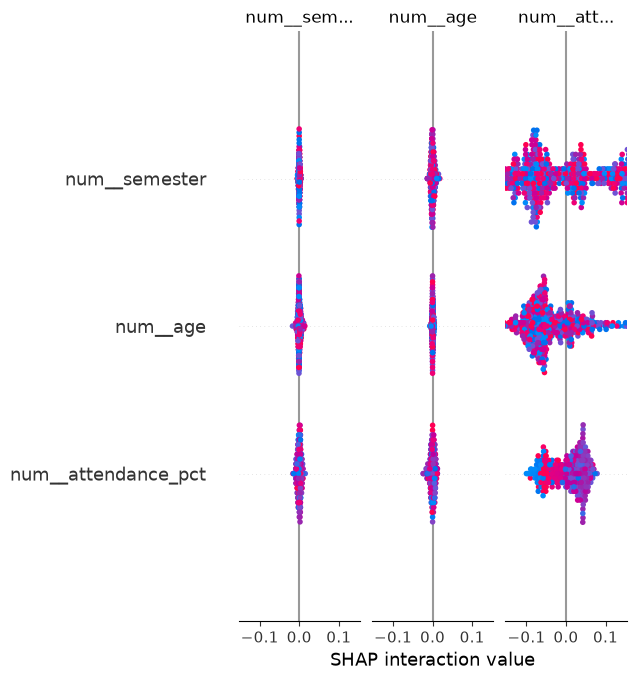

In [68]:
# Global feature importance
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names
)

In [69]:
# Individual student explanation

# Take one test student:
student_index = 0

student_data = X_test_transformed[
    student_index:student_index + 1
]

student_prediction = random_forest_pipeline.predict(
    X_test.iloc[[student_index]]
)

print(
    "Predicted Risk:",
    student_prediction[0]
)

Predicted Risk: Medium


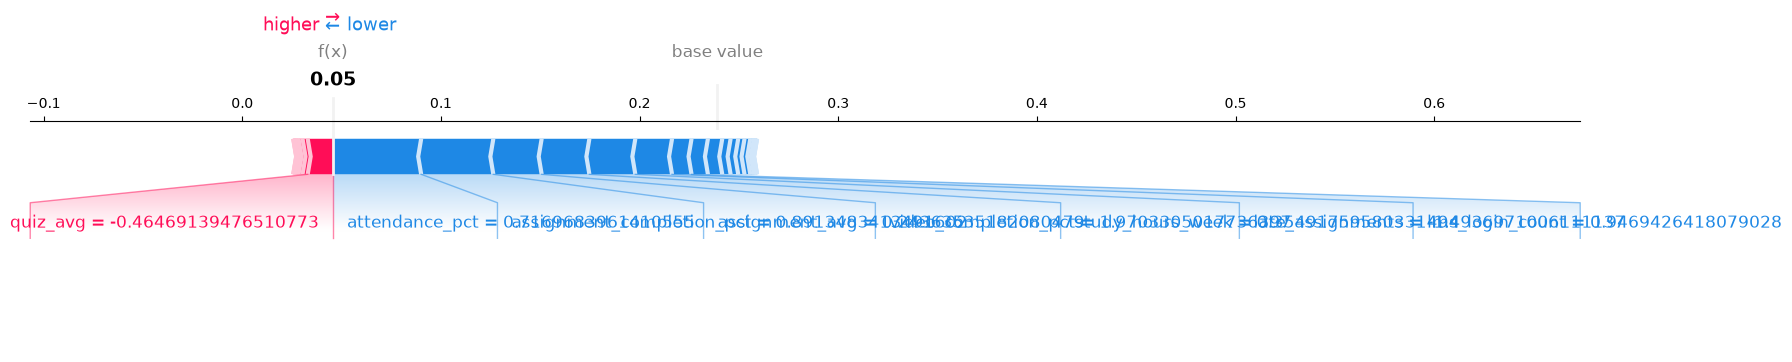

In [71]:
# Fixed SHAP Force Plot for Random Forest (Cell 70)
import shap
import pandas as pd

# 1. Initialize JS for notebook rendering
shap.initjs()

# 2. Reconstruct preprocessed feature names
cat_encoder = preprocessor.named_transformers_['cat'].named_steps['encoder']
encoded_cat_features = cat_encoder.get_feature_names_out(categorical_features).tolist()
all_feature_names = numeric_features + encoded_cat_features

# 3. Transform X_test through preprocessor
X_test_transformed = preprocessor.transform(X_test)
X_test_df = pd.DataFrame(X_test_transformed, columns=all_feature_names)

# 4. Extract the trained Random Forest model from pipeline
rf_model = random_forest_pipeline.named_steps['model']

# 5. Use TreeExplainer (specifically built for Random Forest)
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_df)

# 6. Select student sample index and risk class index
sample_idx = 0   # Student index to analyze (change as needed)
class_idx = 0    # 0 = High Risk, 1 = Low Risk, 2 = Medium Risk

# 7. Extract correct single-class SHAP values safely
if isinstance(shap_values, list): # Older/Standard SHAP output
    base_val = explainer.expected_value[class_idx]
    sample_shap = shap_values[class_idx][sample_idx]
else: # Newer SHAP output format
    base_val = explainer.expected_value[class_idx]
    sample_shap = shap_values[sample_idx, :, class_idx]

# 8. Render Force Plot
shap.force_plot(
    base_val,
    sample_shap,
    X_test_df.iloc[sample_idx],
    matplotlib=True
)

In [73]:
# PART 13 — Personalized Recommendation Engine
def generate_recommendations(student):
    
    recommendations = []

    if student["attendance_pct"] < 75:
        recommendations.append(
            "Improve attendance and attend missed classes regularly."
        )

    if student["assignment_avg"] < 60:
        recommendations.append(
            "Focus on completing assignments and reviewing assignment feedback."
        )

    if student["assignment_completion_pct"] < 70:
        recommendations.append(
            "Complete pending assignments before the next assessment."
        )

    if student["quiz_avg"] < 60:
        recommendations.append(
            "Practice quizzes regularly and revise weak topics."
        )

    if student["study_hours_week"] < 10:
        recommendations.append(
            "Increase weekly study time using a structured study schedule."
        )

    if student["participation_score"] < 60:
        recommendations.append(
            "Increase classroom participation and discussion involvement."
        )

    if student["lms_active_days"] < 12:
        recommendations.append(
            "Use the learning platform more consistently and access available resources."
        )

    if student["previous_gpa"] < 6.0:
        recommendations.append(
            "Review previously difficult subjects and seek academic support."
        )

    if not recommendations:
        recommendations.append(
            "Maintain current learning habits and continue regular revision."
        )

    return recommendations

In [76]:
# Test it
sample_student = X_test.iloc[[0]]

recommendations = generate_recommendations(
    sample_student.iloc[0]
)

for recommendation in recommendations:
    print("•", recommendation)

• Practice quizzes regularly and revise weak topics.
• Increase classroom participation and discussion involvement.


In [81]:
def predict_student_risk(student_data):

    prediction = random_forest_pipeline.predict(
        student_data
    )[0]

    probabilities = random_forest_pipeline.predict_proba(
        student_data
    )[0]

    classes = random_forest_pipeline.classes_

    probability_dict = dict(
        zip(classes, probabilities)
    )

    return prediction, probability_dict

In [82]:
current_risk, current_probabilities = predict_student_risk(
    sample_student
)

print("Predicted Risk:", current_risk)
print("\nRisk Probabilities:")

for risk, probability in current_probabilities.items():
    print(
        f"{risk}: {probability:.2%}"
    )

Predicted Risk: Medium

Risk Probabilities:
High: 4.57%
Low: 41.17%
Medium: 54.26%


In [83]:
#  What-if analysis
def what_if_analysis(
    student_data,
    changes
):

    original = student_data.copy()
    scenario = student_data.copy()

    for feature, value in changes.items():
        scenario[feature] = value

    original_risk, original_probabilities = (
        predict_student_risk(original)
    )

    scenario_risk, scenario_probabilities = (
        predict_student_risk(scenario)
    )

    return {
        "original_risk": original_risk,
        "original_probabilities": original_probabilities,
        "scenario_risk": scenario_risk,
        "scenario_probabilities": scenario_probabilities
    }

In [84]:
# Test
result = what_if_analysis(
    sample_student,
    {
        "attendance_pct": 85
    }
)

print("Original Risk:")
print(result["original_risk"])

print("\nScenario Risk:")
print(result["scenario_risk"])

print("\nOriginal Probabilities:")
print(result["original_probabilities"])

print("\nScenario Probabilities:")
print(result["scenario_probabilities"])

Original Risk:
Medium

Scenario Risk:
Medium

Original Probabilities:
{'High': np.float64(0.04568326118326118), 'Low': np.float64(0.4116920608631137), 'Medium': np.float64(0.542624677953625)}

Scenario Probabilities:
{'High': np.float64(0.04315812890812891), 'Low': np.float64(0.4441506208216735), 'Medium': np.float64(0.5126912502701975)}


In [ ]:
# Trying a stronger what - if scenario
result = what_if_analysis(
    sample_student,
    {
        "attendance_pct": 85,
        "quiz_avg": 70
    }
)

print("Original Risk:", result["original_risk"])
print("Scenario Risk:", result["scenario_risk"])

print("\nOriginal:")
print(result["original_probabilities"])

print("\nWhat-if:")
print(result["scenario_probabilities"])
# The what-if simulator estimates how the model's predicted risk changes when selected input conditions are modified.

Original Risk: Medium
Scenario Risk: Low

Original:
{'High': np.float64(0.04568326118326117), 'Low': np.float64(0.4116920608631137), 'Medium': np.float64(0.5426246779536252)}

What-if:
{'High': np.float64(0.018960594960594965), 'Low': np.float64(0.6402406696617224), 'Medium': np.float64(0.34079873537768285)}


In [88]:
# Create GEN AI prompt
def create_genai_prompt(
    student,
    risk,
    probabilities,
    recommendations
):

    prompt = f"""
You are an educational learning assistant.

Explain the student's performance assessment
in simple, supportive language.

Student information:

Attendance: {student["attendance_pct"]:.1f}%
Assignment average: {student["assignment_avg"]:.1f}
Assignment completion: {student["assignment_completion_pct"]:.1f}%
Quiz average: {student["quiz_avg"]:.1f}
Study hours per week: {student["study_hours_week"]:.1f}
Participation score: {student["participation_score"]:.1f}
LMS active days: {student["lms_active_days"]}
Previous GPA: {student["previous_gpa"]:.2f}
Previous failures: {student["previous_failures"]}
Midterm score: {student["midterm_score"]:.1f}

Predicted risk:
{risk}

Risk probabilities:
{probabilities}

Recommended actions:
{recommendations}

Generate:

1. A short explanation of the predicted risk.
2. The main areas that need attention.
3. A supportive action plan.
4. Clear and simple language.
5. Do not claim that any factor directly causes the outcome.
6. Do not use unnecessary technical ML terminology.
"""

    return prompt

# GenAI explanation

 Student Data
     ↓
Random Forest
     ↓
Risk Prediction + Probability
     ↓
SHAP
     ↓
Important Factors
     ↓
Recommendation Engine
     ↓
LLM / GenAI
     ↓
Simple Natural-Language Explanation

## Part 17 — Integrated Student Analysis Pipeline

This section combines ML prediction, risk probabilities, personalized
recommendations, and GenAI explanation preparation into a single workflow.

In [90]:
def analyze_student(student_data):

    # -----------------------------------------
    # 1. ML prediction
    # -----------------------------------------
    risk, probabilities = predict_student_risk(
        student_data
    )

    # -----------------------------------------
    # 2. Extract student record
    # -----------------------------------------
    student = student_data.iloc[0]

    # -----------------------------------------
    # 3. Generate recommendations
    # -----------------------------------------
    recommendations = generate_recommendations(
        student
    )

    # -----------------------------------------
    # 4. Create GenAI prompt
    # -----------------------------------------
    genai_prompt = create_genai_prompt(
        student,
        risk,
        probabilities,
        recommendations
    )

    # -----------------------------------------
    # 5. Return complete analysis
    # -----------------------------------------
    return {
        "risk": risk,
        "probabilities": probabilities,
        "recommendations": recommendations,
        "genai_prompt": genai_prompt
    }

## Part 18 — Integrated Student Analysis Test

In [91]:
analysis = analyze_student(
    sample_student
)

print("=" * 60)
print("STUDENT PERFORMANCE ANALYSIS")
print("=" * 60)

print("\nPredicted Risk:")
print(analysis["risk"])

print("\nRisk Probabilities:")

for risk, probability in analysis["probabilities"].items():
    print(
        f"{risk}: {probability:.2%}"
    )

print("\nPersonalized Recommendations:")

for recommendation in analysis["recommendations"]:
    print(
        "•",
        recommendation
    )

STUDENT PERFORMANCE ANALYSIS

Predicted Risk:
Medium

Risk Probabilities:
High: 4.57%
Low: 41.17%
Medium: 54.26%

Personalized Recommendations:
• Practice quizzes regularly and revise weak topics.
• Increase classroom participation and discussion involvement.


In [93]:
import json

metadata = {
    "model_name": "Random Forest Classifier",
    "task": "Multiclass Student Risk Classification",
    "classes": list(random_forest_pipeline.classes_),
    "random_state": 42,
    "test_size": 0.20,
    "features": list(X_train.columns),
    "excluded_columns": [
        "student_id",
        "final_score",
        "performance_level",
        "risk_level",
        "gender"
    ]
}

with open(
    "../models/model_metadata.json",
    "w"
) as f:
    json.dump(
        metadata,
        f,
        indent=4
    )

print("Model metadata saved.")

Model metadata saved.


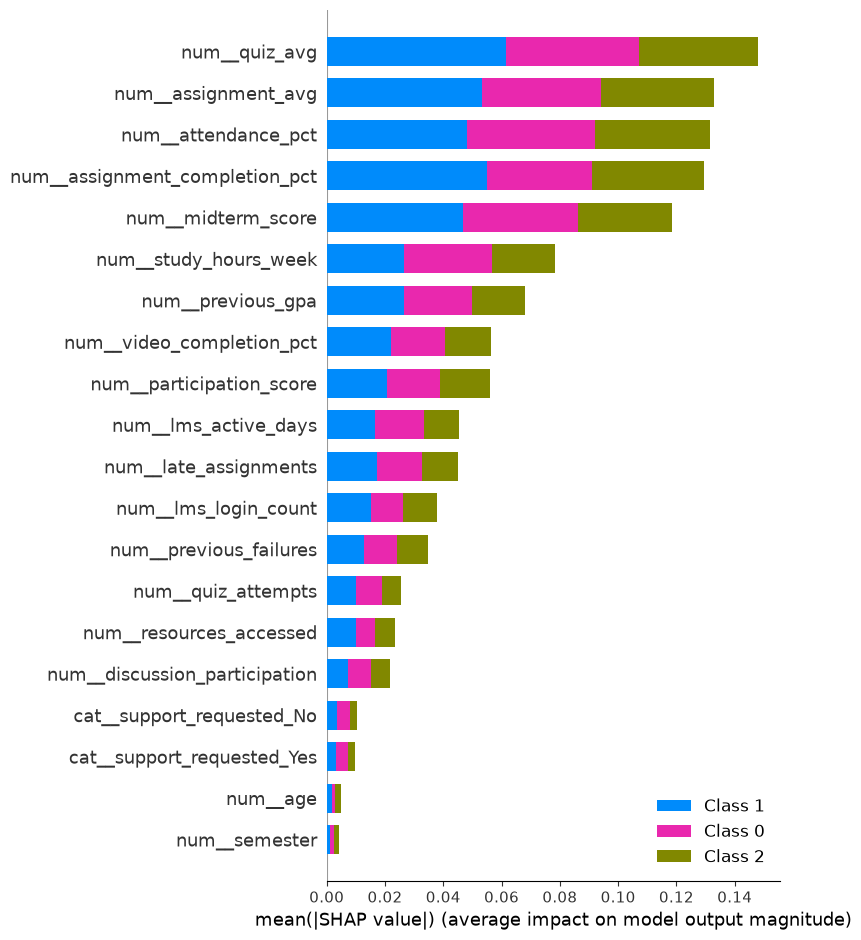

In [95]:
# improve SHAP performance
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    plot_type="bar"
)